# 🏢 Anticipez les besoins en consommations de bâtiments

## 📋 Présentation du Projet
Dans le cadre de son engagement pour la **neutralité carbone d'ici 2050**, la ville de Seattle analyse les données de consommation énergétique de ses bâtiments non résidentiels.

* **Objectif :** Prédire les émissions de CO2 et la consommation totale d'énergie.
* **Cible :** Bâtiments non destinés à l'habitation.

**Question :** 
- Qu'est le plus importa
- Tout le détail que j'ai entré ici doit-il être aussi présent dans les cellules du notebook ? 
- Cette partie là est-elle un bref condensé, le coeur du notebook ?
- Est-ce que j'y ai mis trop de temps et de volume ou l'inverse ?

---

##  1. Imports des modules et du dataset


### Stack Logicielle
| Modules | Version |
| :--- | :---: |
| `Python` | `3.14` |
| `Matplotlib` | `3.10.8` |
| `Pandas` | `3.0.1` |
| `Seaborn` | `0.13.2` |
| `Sickit-learn` | `Texte` |

### Source des données
* **Fichier** : `../data/raw/2016_Building_Energy_Benchmarking.csv`
*  **Format** : CSV

---

##  2. Analyse de la structure des données

###  Dimensions (Shape)
L'appel à `shape` indique que le dataset contient :
* **3 376** lignes
* **46** colonnes


###  Qualité des données (Info)
L'analyse via `info()` montre que plusieurs colonnes comptent un nombre critique de valeurs nulles :
* `Comments`
* `Outlier`
* `YearsENERGYSTARCertified`
* `ThirdLargestPropertyUseType`

La colonne `ListOfAllPropertyUseTypes` sera difficilement exploitable par le modèle (liste sous forme de string).


###  Statistiques descriptives (Describe)

| Variables | Observations | Déductions |
| :--- | :--- | :--- |
| `NumberofBuildings` | 75% à 1 et Max à 111 | Présence d'**outliers** marqués. |
| `NumberofFloors` | Max à 99, alors que 75% sont à 5 | Présence potentielle d'**outliers**. |
| `Electricity(kBtu)` | Valeur min négative (`-1.154e+05`) | **Valeurs aberrantes** à corriger. |

> **Note sur le nettoyage :** Les variables `DataYear`, `Comments`, `City` et `States` disposent d'une valeur unique ou sont vides. 


---

##  3. Analyse des données (fond) :
| Variables | Pourcentage de valeurs vides | Déductions |
| :--- | :---: | :--- |
| `Outliers` | 99.052133% | Outliers connus du dataset -> suppression des lignes avec une valeurs puis suppression de la colonne |
| `Comments` | 100% | Colonne vide -> à supprimer |
| `YearsENERGYSTARCertified` | 96.475118% | Trop peu de valeurs -> à supprimer |
| `ThirdLargestPropertyUseType` | 82.345972% | Trop peu de valeurs mais utile via feature engineering |
| `ThirdLargestPropertyUseTypeGFA` | 82.345972% | Trop peu de valeurs mais utile via feature engineering |
| `DefaultData` | 96.652844% | Faible pourcentage de valeurs entrée par défaut donc on peut supprimer |

**Questions**
Diagramme en barre à faire à l'horizontal 


---

## 4. Suppression des lignes et des colonnes inutiles

### Cible
Notre variable cible sera `SiteEnergyUseWN(kBtu)` :
- L'objectif de l'analyse est d'anticiper la consommation energetique ce qui correspond à cette variable
- Mesure en kBtu et WN qui sont des indicateurs universelles
- La colonne est rempli à 99.48%



### Filtrage des lignes
- L'étude porte sur les batiments non résidentiel. On ne conservera donc que les lignes de `BuildingType` n'ayant pas la mention "Multifamily" dans leur libellé.
- On supprime les lignes ayant un outlier connu du dataset en se basant sur les valeurs non vides de `Outlier`.
- Suppression des lignes avec des valeurs par défaut ajoutée `DefaultData`.
- Suppression des lignes avec des valeurs vides dans `SiteEnergyUseWN(kBtu)`.


### Filtrage des colonnes
**Post analyse exploratoire**

Colonnes qui se révèlent inutile suite à l'analyse exploratoire
| Variables | Justification |
| :--- | :--- |
| `Outliers` | Post-filtre, ne dispose plus que de valeurs vides |
| `Comments` | Colonne vide |
| `DataYear` | Valeur unique |
| `City` | Valeur unique |
| `States` | Valeur unique |
| `YearsENERGYSTARCertified`|Trop peu de valeurs|
| `ListOfAllPropertyUseTypes`|Difficilement exploitable pour le modèle|

**Carateristiques du batiment**
Plusieurs variables de localisation et d'identification de batiment redondantes.

Choix de garder latitude et longitude :
- Plus simple à traiter que des strings pour les adresses
- Meilleur précision geographique
- L'indice du dataframe nous permettra d'identifier chaque batiment
- `ComplianceStatus` n'a aucune valeur pour la prediction


| Variables | Justification |
| :--- | :--- |
| `Address` | Redondance de localisation |
| `ZipCode` | Redondance de localisation |
| `TaxParcelIdentificationNumber` | Redondance de localisation |
| `OSEBuildingID` | Redondance d'identification' |
| `ComplianceStatus` | Aucune utilité pour le modèle|


**Unite de mesure**

- Utilisations de l'unité de mesure kBtu car unité de mesure universelle
- Priorisation des Données normalisés Wn car plus fiable que les données de consomation brutes (WN = ajusté à la mété)
- Elimination des données composantes

| Variables | Justification |
| :--- | :--- |
| `Electricity(kWh)` | Equivalent existant WN |
| `NaturalGas(therms)` | Equivalent existant WN |
| `SiteEnergyUse(kBtu)` | Equivalent existant WN |
| `SiteEUI(kBtu/sf) ` | Equivalent existant WN |
| `SourceEUI(kBtu/sf)` | Equivalent existant WN |
| `SiteEnergyUse(kBtu)` | Equivalent existant WN |
| `NaturalGas(kBtu)` | Composantes de la variable cible |
| `SteamUse(kBtu)` | Composantes de la variable cible |
| `Electricity(kBtu)` | Composantes de la variable cible |
| `TotalGHGEmissions` | Calculé à partir de la variable cible|
| `GHGEmissionsIntensity` | Calculé à partir de la variable cible |


Dimension post filtrage :
* **1562** lignes
* **20** colonnes

**Questions**
- A quel point faut-il argumenter ici dans le choix des colonnes à conserver ?
- Garder OSEBuildingID pour identifier le batiment ? ou l'indice du dataframe est suffisant ?


## 5. Traitement des valeurs aberantes et impossibles
Valeurs impossibles,  (ex: yearbuilt = 2040)
Valeurs aberrantes, à traiter/visualiser avec Boxplot
Arbitrage de ce qu'on fait pour ces valeurs là (remplacement, suppression)

A l'issue, plus de valeurs inutiles et vides

## 6. Analyse univarié
Analyse univarié, sur une variable (voir lien compte rendu)

## 7. Analyse bivarié
Analyse bivarié, sur plusieurs features (trouver les corrélations)

Dégager des hypothèses à partir des différentes représentations et graphiques

Encodage des données pour la modélisation : On ne peut pas faire d'algorithme de classification sur des string, il faut donc les convertir en donnés utilisable

Feature engineering, créer une nouvelle variable à partir d'autres variables existantes

DataSet prêt à l'emploi et à sauvegarder


##  1. Imports des modules et du dataset


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import dis
from scipy import stats
from category_encoders.binary import BinaryEncoder
from sklearn import preprocessing

In [ ]:
building_consumption = pd.read_csv("../data/raw/2016_Building_Energy_Benchmarking.csv")

## 2. Analyse de la structure des données

In [ ]:
# Dimension du dataset
building_consumption.shape

(3376, 46)

In [ ]:
# Première aperçu du dataset
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [ ]:
# Première aperçu de la qualité des données
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [ ]:
building_consumption.describe(include='all')

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3376,3376,3376,3376,3376,3376,3360.000000,3376,...,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3376,0.0,3376,32,3367.000000,3367.000000
unique,NaN,NaN,8,24,3362,3354,1,1,NaN,3268,...,NaN,NaN,NaN,NaN,2,NaN,4,2,NaN,NaN
top,NaN,NaN,NonResidential,Low-Rise Multifamily,Northgate Plaza,2600 SW Barton St,Seattle,WA,NaN,1625049001,...,NaN,NaN,NaN,NaN,False,NaN,Compliant,Low outlier,NaN,NaN
freq,NaN,NaN,1460,987,3,4,3376,3376,NaN,8,...,NaN,NaN,NaN,NaN,3263,NaN,3211,23,NaN,NaN
mean,21208.991114,2016.0,NaN,NaN,NaN,NaN,NaN,NaN,98116.949107,NaN,...,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,NaN,NaN,NaN,119.723971,1.175916
std,12223.757015,0.0,NaN,NaN,NaN,NaN,NaN,NaN,18.615205,NaN,...,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,NaN,NaN,NaN,538.832227,1.821452
min,1.000000,2016.0,NaN,NaN,NaN,NaN,NaN,NaN,98006.000000,NaN,...,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,NaN,NaN,NaN,NaN,NaN,NaN,98105.000000,NaN,...,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,9.495000,0.210000
50%,23112.000000,2016.0,NaN,NaN,NaN,NaN,NaN,NaN,98115.000000,NaN,...,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,NaN,NaN,NaN,33.920000,0.610000
75%,25994.250000,2016.0,NaN,NaN,NaN,NaN,NaN,NaN,98122.000000,NaN,...,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,NaN,NaN,NaN,93.940000,1.370000


In [ ]:
building_consumption["BuildingType"].value_counts()

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

## 3. Analyse des données (fond) 

In [ ]:
remplissage = (building_consumption.notna().mean() * 100).sort_values(ascending=False)
display(remplissage)


OSEBuildingID                      100.000000
DataYear                           100.000000
BuildingType                       100.000000
PrimaryPropertyType                100.000000
PropertyName                       100.000000
Address                            100.000000
City                               100.000000
State                              100.000000
TaxParcelIdentificationNumber      100.000000
CouncilDistrictCode                100.000000
Latitude                           100.000000
Neighborhood                       100.000000
Longitude                          100.000000
YearBuilt                          100.000000
PropertyGFABuilding(s)             100.000000
NumberofFloors                     100.000000
PropertyGFATotal                   100.000000
PropertyGFAParking                 100.000000
DefaultData                        100.000000
ComplianceStatus                   100.000000
SiteEnergyUse(kBtu)                 99.851896
SiteEUIWN(kBtu/sf)                

## 4. Suppression des lignes et des colonnes inutiles

### Cible

In [ ]:
building_consumption["SiteEnergyUseWN(kBtu)"].describe()


count    3.370000e+03
mean     5.276726e+06
std      1.593879e+07
min      0.000000e+00
25%      9.701822e+05
50%      1.904452e+06
75%      4.381429e+06
max      4.716139e+08
Name: SiteEnergyUseWN(kBtu), dtype: float64

In [ ]:
building_consumption["BuildingType"].value_counts()

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

### Filtrage par ligne

-  : Suppression des batiments nommés Multifamily et Campus (élèves qui habitent sur place)
- Outlier identifiés : Suppression des valeurs non vides d'`Outlier`
- DefaultData

In [ ]:
# Filtre des batiments non destinés à l'habitation
building_consumption = building_consumption[building_consumption["BuildingType"].isin(["NonResidential", "SPS-District K-12", "Nonresidential COS", "Nonresidential WA"])].copy()

# Filtre des lignes ayant un outlier identifié
building_consumption = building_consumption[building_consumption["Outlier"].isna()].copy()

#Filtre des lignes ayant des données entrées par défaut
building_consumption = building_consumption[building_consumption["DefaultData"]!= True].copy()

#Filtre des lignes ayant des valeurs vides dans SiteEnergyUseWN(kBtu)
building_consumption = building_consumption[~building_consumption["SiteEnergyUseWN(kBtu)"].isna()].copy()

# Filtre des lignes n'etant pas "Compliant"
building_consumption = building_consumption[building_consumption["ComplianceStatus"] == "Compliant"].copy()

# Filtre des lignes residence Hall
building_consumption = building_consumption[building_consumption["PrimaryPropertyType"] != "Residence Hall"].copy()

EnergySTARScore est utile mais vide à 75%, on va donc remplacer les valeurs vides par la mediane de la colonne

In [ ]:

building_consumption["ENERGYSTARScore"] = building_consumption["ENERGYSTARScore"].fillna(
    building_consumption["ENERGYSTARScore"].median()
)

building_consumption.info()

<class 'pandas.DataFrame'>
Index: 1502 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1502 non-null   int64  
 1   DataYear                         1502 non-null   int64  
 2   BuildingType                     1502 non-null   str    
 3   PrimaryPropertyType              1502 non-null   str    
 4   PropertyName                     1502 non-null   str    
 5   Address                          1502 non-null   str    
 6   City                             1502 non-null   str    
 7   State                            1502 non-null   str    
 8   ZipCode                          1489 non-null   float64
 9   TaxParcelIdentificationNumber    1502 non-null   str    
 10  CouncilDistrictCode              1502 non-null   int64  
 11  Neighborhood                     1502 non-null   str    
 12  Latitude                         150

### Filtrage par colonne

In [ ]:
# Nettoyage des colonnes inutiles
building_consumption = building_consumption[[ 
    #'OSEBuildingID','DataYear', 
       #'BuildingType', 
       'PrimaryPropertyType',
       #'PropertyName', 'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 
       'Neighborhood',
       #'Latitude', 'Longitude', 
       'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 
       #'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       #'YearsENERGYSTARCertified', 
       'ENERGYSTARScore', 
       #'SiteEUI(kBtu/sf)',
       #'SiteEUIWN(kBtu/sf)', 
       #'SourceEUI(kBtu/sf)', 
       #'SourceEUIWN(kBtu/sf)',
       #'SiteEnergyUse(kBtu)', 
       'SiteEnergyUseWN(kBtu)', 
       'SteamUse(kBtu)',
       #'Electricity(kWh)', 
       'Electricity(kBtu)', 
       #'NaturalGas(therms)',
       'NaturalGas(kBtu)', 
       # 'DefaultData', 'Comments', 'ComplianceStatus', 'Outlier', 
       #'TotalGHGEmissions', 
       'GHGEmissionsIntensity'

]].copy()
display(building_consumption)

,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity
0,Hotel,DOWNTOWN,1927,1.0,12,88434,0,88434,Hotel,88434.0,NaN,NaN,NaN,NaN,60.0,7.456910e+06,2003882.00,3.946027e+06,1.276453e+06,2.83
1,Hotel,DOWNTOWN,1996,1.0,11,103566,15064,88502,Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,61.0,8.664479e+06,0.00,3.242851e+06,5.145082e+06,2.86
2,Hotel,DOWNTOWN,1969,1.0,41,956110,196718,759392,Hotel,756493.0,NaN,NaN,NaN,NaN,43.0,7.393711e+07,21566554.00,4.952666e+07,1.493800e+06,2.19
3,Hotel,DOWNTOWN,1926,1.0,10,61320,0,61320,Hotel,61320.0,NaN,NaN,NaN,NaN,56.0,6.946800e+06,2214446.25,2.768924e+06,1.811213e+06,4.67
4,Hotel,DOWNTOWN,1980,1.0,18,175580,62000,113580,Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,75.0,1.465650e+07,0.00,5.368607e+06,8.803998e+06,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3370,Other,DELRIDGE NEIGHBORHOODS,1982,1.0,1,18261,0,18261,Other - Recreation,18261.0,NaN,NaN,NaN,NaN,71.0,1.025432e+06,0.00,6.323620e+05,2.997200e+05,1.11
3372,Other,DOWNTOWN,2004,1.0,1,16000,0,16000,Other - Recreation,16000.0,NaN,NaN,NaN,NaN,71.0,1.053706e+06,0.00,3.965461e+05,5.537300e+05,2.01
3373,Other,MAGNOLIA / QUEEN ANNE,1974,1.0,1,13157,0,13157,Other - Recreation,7583.0,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,71.0,6.053764e+06,0.00,1.792159e+06,3.973739e+06,16.99
3374,Mixed Use Property,GREATER DUWAMISH,1989,1.0,1,14101,0,14101,Other - Recreation,6601.0,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,71.0,7.828413e+05,0.00,3.488702e+05,3.706010e+05,1.57


In [ ]:
building_consumption.shape

(1502, 20)

## 5.Traitement des valeurs aberrantes et impossibles

In [ ]:
building_consumption.describe()

,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity
count,1502.000000,1502.000000,1502.000000,1.502000e+03,1502.000000,1.502000e+03,1.498000e+03,824.000000,339.000000,1502.000000,1.502000e+03,1.502000e+03,1.502000e+03,1.502000e+03,1502.000000
mean,1961.639148,1.035286,4.311585,1.130402e+05,14065.268309,9.897492e+04,9.128223e+04,35400.550118,13567.682592,66.241012,7.884148e+06,5.051918e+05,5.512141e+06,1.711911e+06,1.628242
std,32.780928,0.567338,6.863385,1.912363e+05,44206.171464,1.672759e+05,1.561913e+05,62955.845537,28220.036650,23.489359,1.902221e+07,5.378705e+06,1.316013e+07,5.577337e+06,2.264918
min,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.000000e+00,0.000000e+00,-1.154170e+05,0.000000e+00,-0.020000
25%,1930.000000,1.000000,1.000000,2.884175e+04,0.000000,2.791425e+04,2.500525e+04,5406.000000,2613.500000,60.000000,1.298629e+06,0.000000e+00,7.270342e+05,0.000000e+00,0.350000
50%,1965.000000,1.000000,2.000000,4.799650e+04,0.000000,4.591200e+04,4.161650e+04,12062.500000,5837.000000,71.000000,2.788274e+06,0.000000e+00,1.699671e+06,4.557595e+05,0.870000
75%,1988.000000,1.000000,4.000000,1.034245e+05,0.000000,9.364750e+04,8.918275e+04,31770.750000,12379.500000,79.000000,7.409108e+06,0.000000e+00,5.160990e+06,1.465539e+06,1.937500
max,2015.000000,9.000000,99.000000,1.952220e+06,512608.000000,1.765970e+06,1.680937e+06,441551.000000,303910.000000,100.000000,2.966717e+08,1.349435e+08,2.745325e+08,1.381912e+08,25.710000


### Valeurs impossibles

D'après notre describe, nous avons des valeurs impossibles dans la colonne `Electricity(kBtu)` (valeurs negatives) et des valeurs égale à 0 dans `NumberofBuildings` :  

- Un filtrage sera donc fait pour retirer les consommations d'électricité négatives.
- Il faudra regarder le type de batiments ayant `NumberofBuildings` égale à 0

Nous retirons aussi les consommations energetiques total valant 0. Un batiment consomme forcément de l'énergie sauf si il est abandonné.

In [ ]:
building_consumption = building_consumption[building_consumption["Electricity(kBtu)"] > 0].copy()
building_consumption = building_consumption[building_consumption["SiteEnergyUseWN(kBtu)"] > 0].copy()

In [ ]:
numberofbuildings_a_0 = building_consumption[building_consumption["NumberofBuildings"] == 0 ]
#display(numberofbuildings_a_0)

En observant la distribution des différents batiments concernés, une correction de remplacer le 0 par un 1 semble juste.

In [ ]:
building_consumption["NumberofBuildings"] = building_consumption["NumberofBuildings"].replace(0,1)

Pour le nombre d'étage, pour éviter des gaps très incohérents entre la surface et la taille du batiment, on va remplacer le 0 par la mediane du nombre d'étage pour chaque type de batiments

In [ ]:
# On remplace toutes les valeurs valant 0 par nan pour pouvoir utiliser la fonction fillna
building_consumption["NumberofFloors"] = building_consumption["NumberofFloors"].replace(0, np.nan)

# On remplace par la mediane pour chaque PrimaryPropertyType
building_consumption["NumberofFloors"] = building_consumption["NumberofFloors"].fillna(
    building_consumption.groupby("PrimaryPropertyType")["NumberofFloors"].transform("median")
)

# On repasse les valeurs en entier pour éviter "Nombre d'étages = 3.5"
building_consumption["NumberofFloors"] = building_consumption["NumberofFloors"].astype(int)

In [ ]:
building_consumption.describe()

,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity
count,1491.000000,1491.000000,1491.000000,1.491000e+03,1491.000000,1.491000e+03,1.487000e+03,820.000000,337.000000,1491.000000,1.491000e+03,1.491000e+03,1.491000e+03,1.491000e+03,1491.000000
mean,1961.594903,1.069752,4.309188,1.128110e+05,14018.168343,9.879287e+04,9.111905e+04,35292.372313,13588.324625,66.208585,7.925588e+06,4.996828e+05,5.499310e+06,1.716173e+06,1.625661
std,32.738473,0.535170,6.854502,1.914898e+05,44235.922264,1.675927e+05,1.564937e+05,63019.363315,28300.405529,23.525627,1.908177e+07,5.391287e+06,1.317784e+07,5.590550e+06,2.248753
min,1900.000000,1.000000,1.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,5.811420e+04,0.000000e+00,3.000000e+00,0.000000e+00,0.010000
25%,1930.000000,1.000000,1.000000,2.881400e+04,0.000000,2.785700e+04,2.500000e+04,5375.000000,2592.000000,60.000000,1.319332e+06,0.000000e+00,7.295085e+05,0.000000e+00,0.350000
50%,1965.000000,1.000000,2.000000,4.783600e+04,0.000000,4.574300e+04,4.159100e+04,12000.000000,5837.000000,71.000000,2.805826e+06,0.000000e+00,1.699362e+06,4.621940e+05,0.870000
75%,1988.000000,1.000000,4.000000,1.030000e+05,0.000000,9.358250e+04,8.910300e+04,31447.500000,12359.000000,79.000000,7.424380e+06,0.000000e+00,5.152340e+06,1.473314e+06,1.940000
max,2015.000000,9.000000,99.000000,1.952220e+06,512608.000000,1.765970e+06,1.680937e+06,441551.000000,303910.000000,100.000000,2.966717e+08,1.349435e+08,2.745325e+08,1.381912e+08,25.710000


### Outliers

Potentiel Outliers :
- NumberofFloors

Text(0.5, 1.0, 'Boxplot de la distribution de GHGEmissionsIntensity par PrimaryPropertyType')

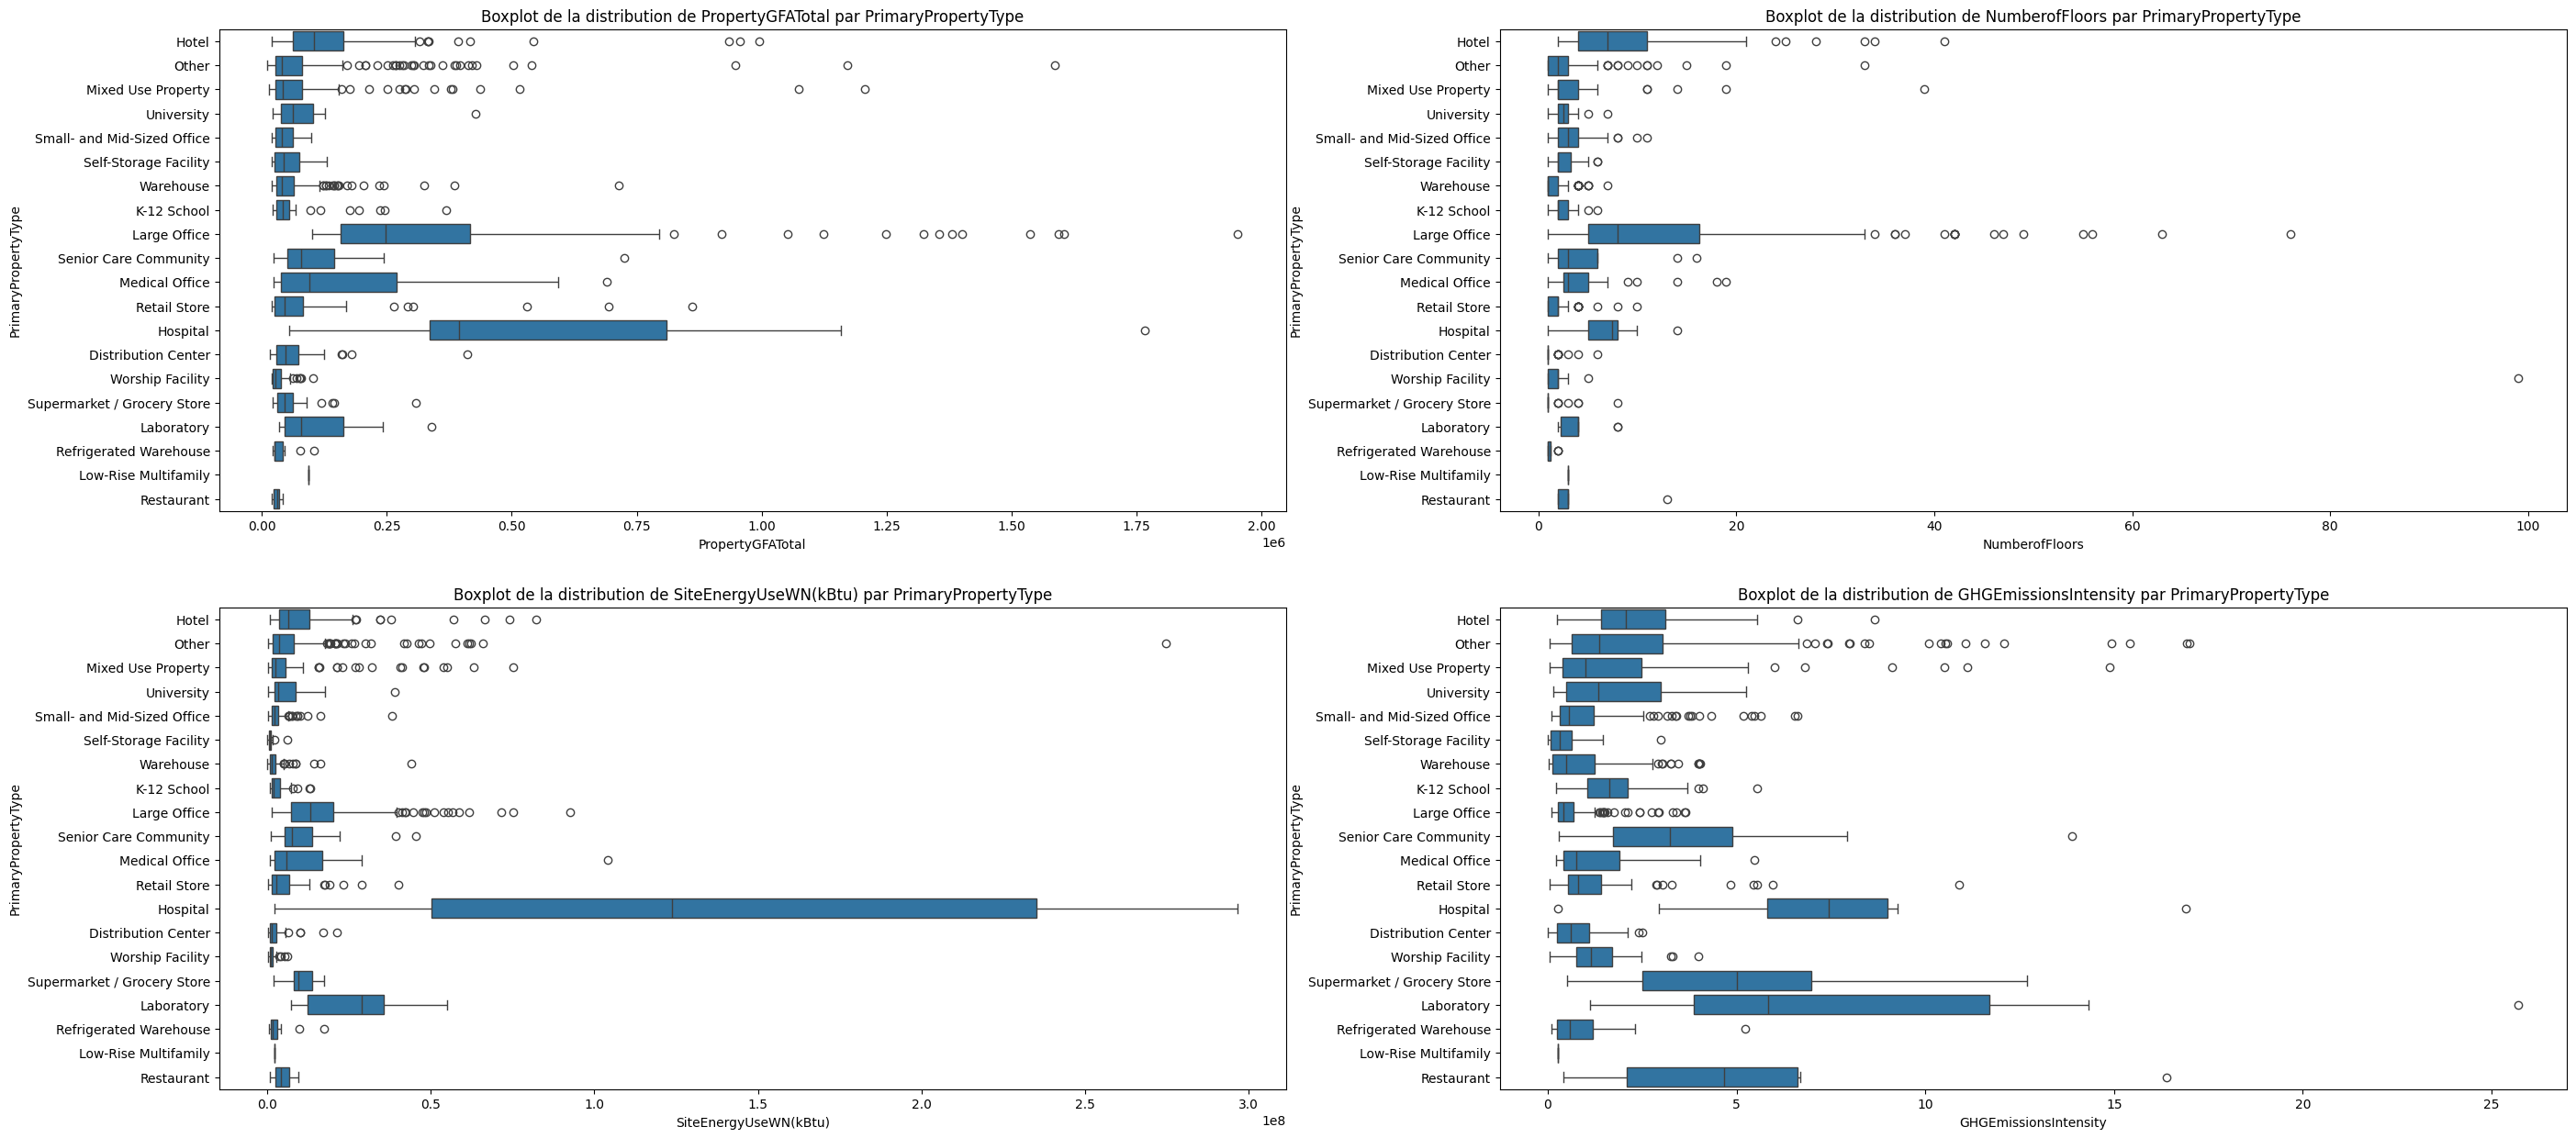

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(33,15))
sns.boxplot(x=building_consumption["PropertyGFATotal"], y=building_consumption["PrimaryPropertyType"], 
            ax=axes[0][0]).set_title("Boxplot de la distribution de PropertyGFATotal par PrimaryPropertyType")

sns.boxplot(x=building_consumption["NumberofFloors"], y=building_consumption["PrimaryPropertyType"], 
            ax=axes[0][1]).set_title("Boxplot de la distribution de NumberofFloors par PrimaryPropertyType")

sns.boxplot(x=building_consumption["SiteEnergyUseWN(kBtu)"], y=building_consumption["PrimaryPropertyType"], 
            ax=axes[1][0]).set_title("Boxplot de la distribution de SiteEnergyUseWN(kBtu) par PrimaryPropertyType")

sns.boxplot(x=building_consumption["GHGEmissionsIntensity"], y=building_consumption["PrimaryPropertyType"], 
            ax=axes[1][1]).set_title("Boxplot de la distribution de GHGEmissionsIntensity par PrimaryPropertyType")


La grande disparité du secteur immobilier est la raison pour laquelle il y a beaucoup d'outlier dans notre dataset.

Sur ces boxplots, 2 retiennent notre attention :
- Un lieu de culte avec 99 étages
- Un batiment catégorisé Other avec une consommation particulièrement importante 

Le nombre d'étage du lieu de culte sera ramené à un

In [ ]:
building_consumption["NumberofFloors"] = building_consumption["NumberofFloors"].replace(99, 1)
outlier_other = building_consumption[(building_consumption["PrimaryPropertyType"] == "Other") & (building_consumption["SiteEnergyUseWN(kBtu)"] > 100000000)]
display(outlier_other)


,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity
558,Other,DOWNTOWN,1981,1.0,33,429405,0,429405,Data Center,218997.0,Office,210409.0,NaN,NaN,98.0,274725984.0,0.0,274532495.0,149672.0,4.48


La valeur aberrante de consommation d'énergie correspond à un Datacenter. On fait donc face ici à une valeur atypique que l'on doit prendre en compte.


Certains modèles étant très sensibles aux outliers, il pourra être pertinent de créer des colonnes en prenant le logarithme des valeurs présentes pour réduire l'impact des outliers sur le modèle tout en conservant les valeurs extrèmes.

## 6. Analyse univarié

Text(0.5, 1.0, 'Histogramme de PropertyGFABuilding(s)')

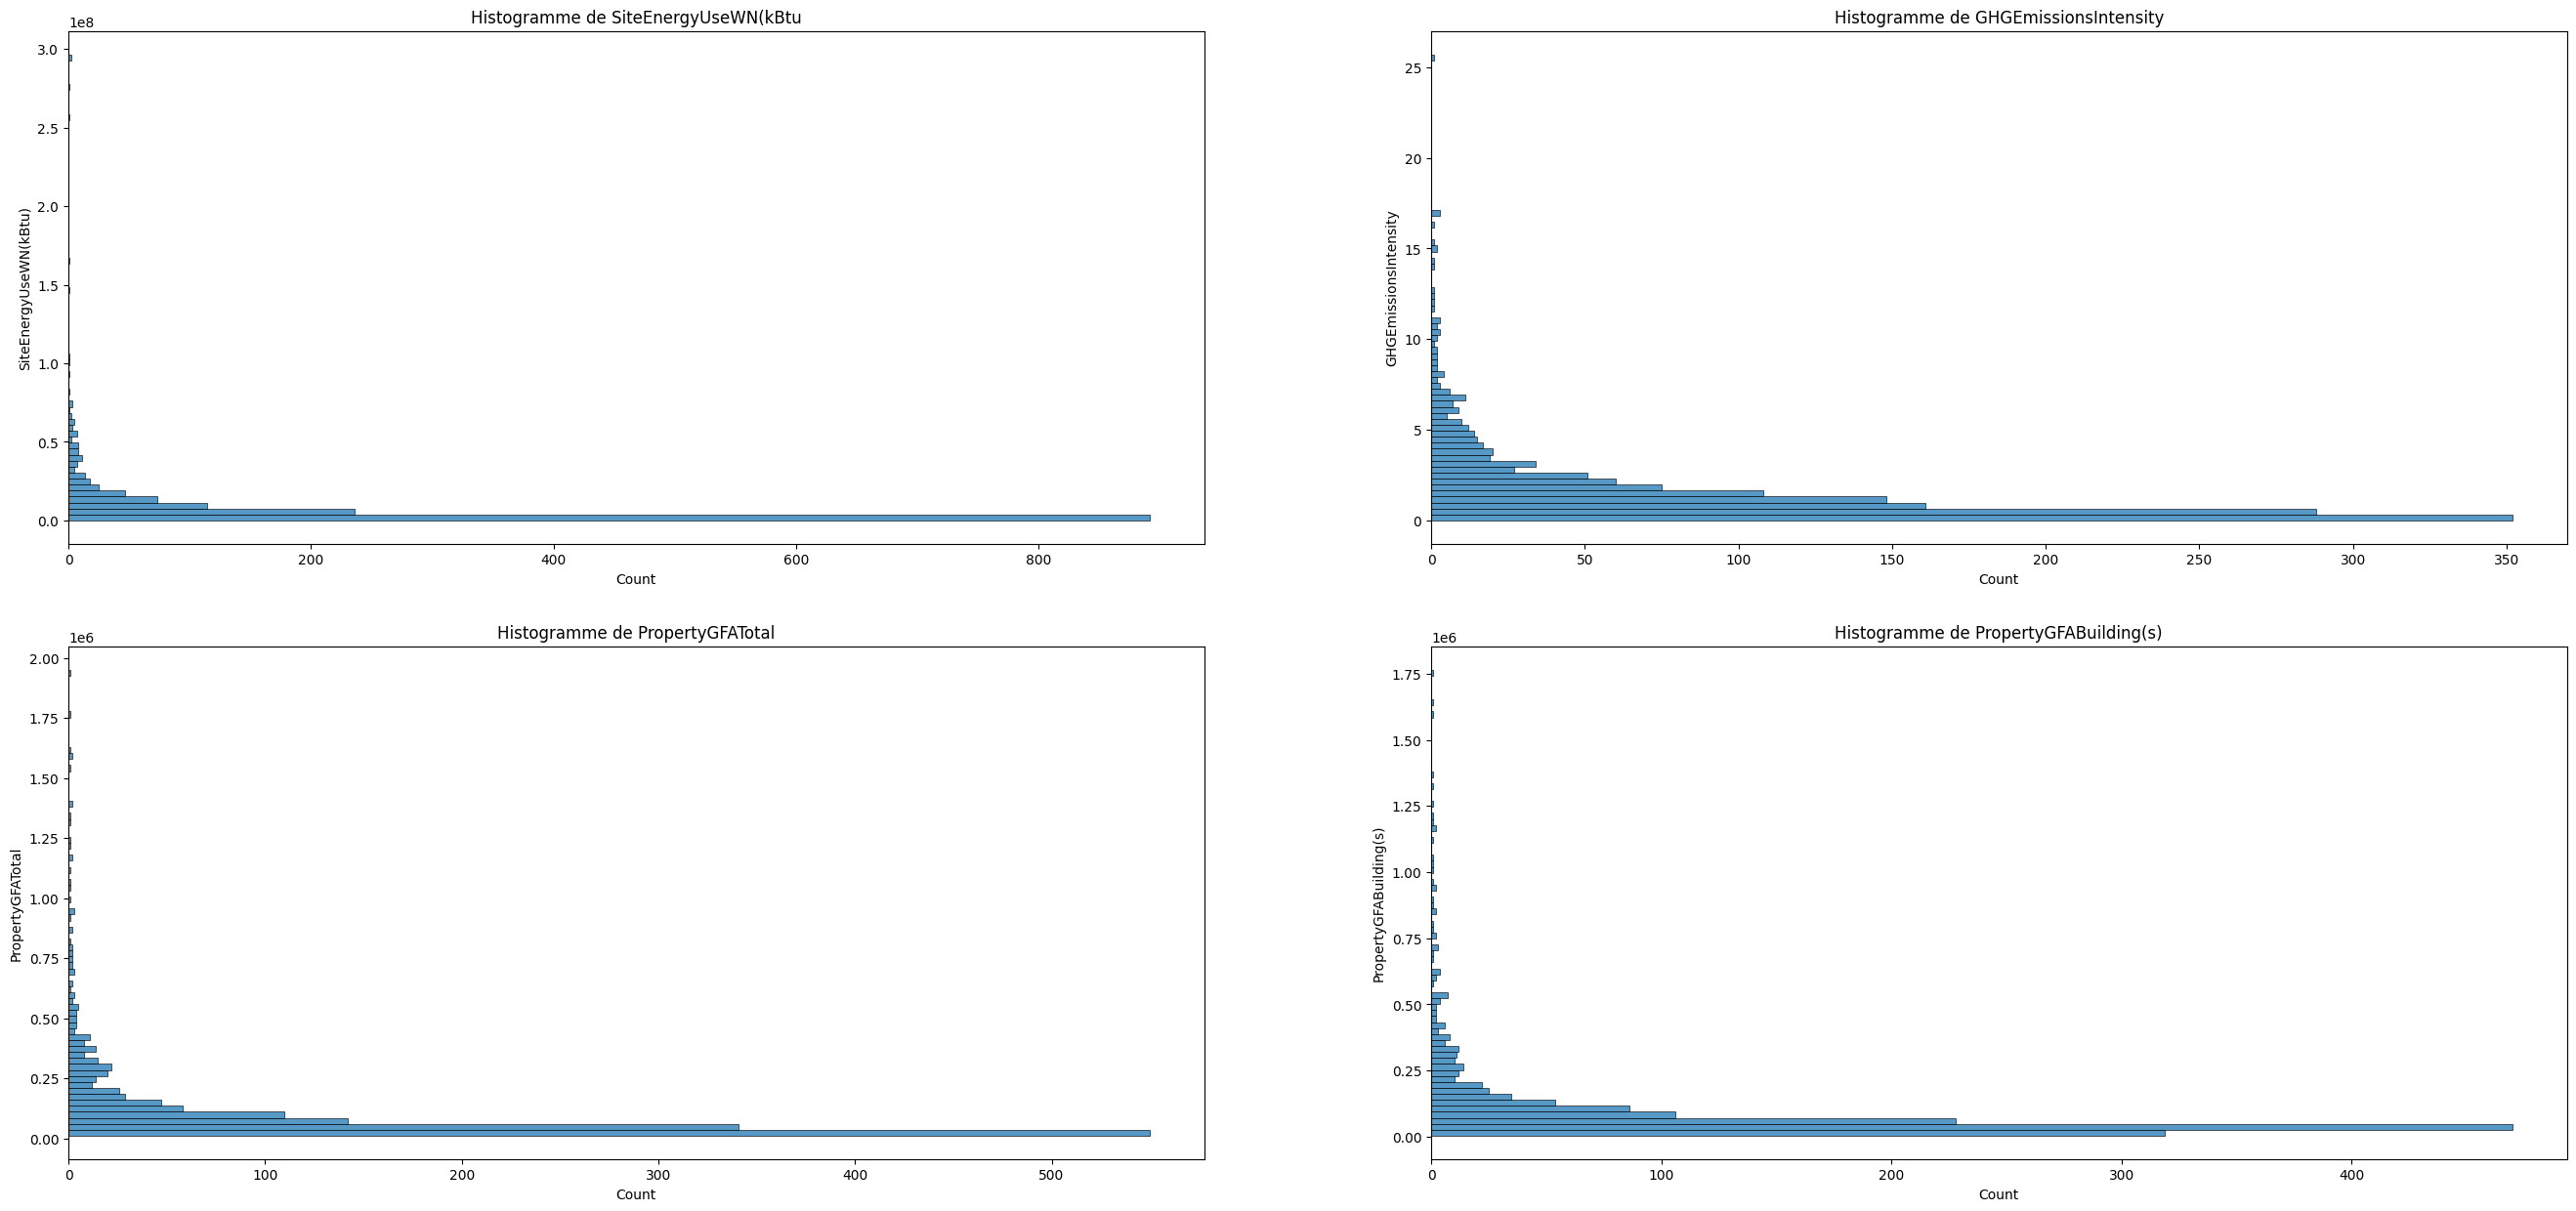

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(33,15))
sns.histplot(data=building_consumption, y="SiteEnergyUseWN(kBtu)", ax=axes[0][0]).set_title("Histogramme de SiteEnergyUseWN(kBtu")
sns.histplot(data=building_consumption, y="GHGEmissionsIntensity", ax=axes[0][1]).set_title("Histogramme de GHGEmissionsIntensity")
sns.histplot(data=building_consumption, y="PropertyGFATotal", ax=axes[1][0]).set_title("Histogramme de PropertyGFATotal")
sns.histplot(data=building_consumption, y="PropertyGFABuilding(s)", ax=axes[1][1]).set_title("Histogramme de PropertyGFABuilding(s)")



In [ ]:
analyse_univarie = building_consumption[["PropertyGFATotal", "SiteEnergyUseWN(kBtu)", "GHGEmissionsIntensity", "PropertyGFABuilding(s)"]].describe()
display(analyse_univarie)

,PropertyGFATotal,SiteEnergyUseWN(kBtu),GHGEmissionsIntensity,PropertyGFABuilding(s)
count,1.491000e+03,1.491000e+03,1491.000000,1.491000e+03
mean,1.128110e+05,7.925588e+06,1.625661,9.879287e+04
std,1.914898e+05,1.908177e+07,2.248753,1.675927e+05
min,1.128500e+04,5.811420e+04,0.010000,3.636000e+03
25%,2.881400e+04,1.319332e+06,0.350000,2.785700e+04
50%,4.783600e+04,2.805826e+06,0.870000,4.574300e+04
75%,1.030000e+05,7.424380e+06,1.940000,9.358250e+04
max,1.952220e+06,2.966717e+08,25.710000,1.765970e+06


En observant ces 3 variables, on observe pour toute une asymétrie vers la droite. On peut donc en déduire que la plupart des batiments sont de petites tailles et ont une faible consommation mais la moyenne est tirée par le haut par des batiments ayant des valeurs extrêmes


<Axes: xlabel='count', ylabel='PrimaryPropertyType'>

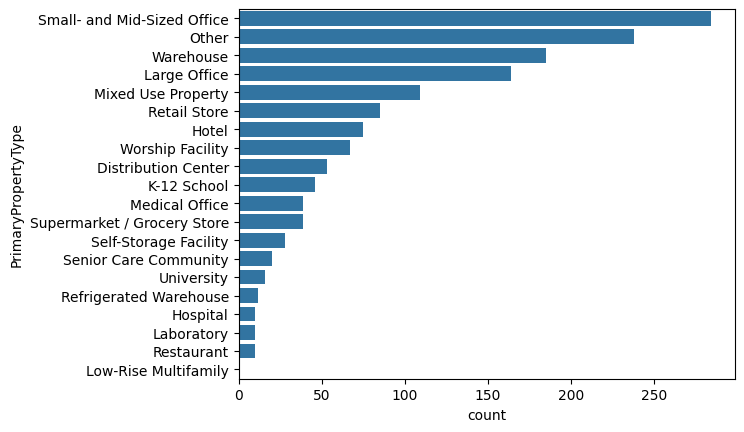

In [ ]:
sns.countplot(data=building_consumption, y="PrimaryPropertyType", order=building_consumption["PrimaryPropertyType"].value_counts().index)

In [ ]:
display(building_consumption["PrimaryPropertyType"].value_counts(normalize=True) * 100)

PrimaryPropertyType
Small- and Mid-Sized Office    19.047619
Other                          15.962441
Warehouse                      12.407780
Large Office                   10.999329
Mixed Use Property              7.310530
Retail Store                    5.700872
Hotel                           5.030181
Worship Facility                4.493628
Distribution Center             3.554661
K-12 School                     3.085178
Medical Office                  2.615694
Supermarket / Grocery Store     2.615694
Self-Storage Facility           1.877934
Senior Care Community           1.341382
University                      1.073105
Refrigerated Warehouse          0.804829
Hospital                        0.670691
Laboratory                      0.670691
Restaurant                      0.670691
Low-Rise Multifamily            0.067069
Name: proportion, dtype: float64

On observe que les 4 catégories les plus représentées représentent 66% de toutes la population.

Note : les hopitaux ne représentent que 0.7% des batiments mais sont parmi les plus gros consommateurs.

## 7. Analyse bivarié

Notre dataset étant fortement exposé aux outliers, nous allons créer des nouvelles colonnes en prenant le logs des valeurs energetiques :
- Pour avoir un meilleur rendu visuel sur nos visualisations
- Certains modèles étant sensibles aux outliers, l'utilisation d'une colonne logarithme permet de réduire l'influence des valeurs extrêmes sans s'en séparer

In [ ]:
building_consumption["LogSiteEnergyUseWN(kBtu)"] = np.log1p(building_consumption["SiteEnergyUseWN(kBtu)"])
building_consumption["LogPropertyGFATotal"] = np.log1p(building_consumption["PropertyGFATotal"])
building_consumption["LogPropertyGFABuilding(s)"] = np.log1p(building_consumption["PropertyGFABuilding(s)"])
building_consumption["LogLargestPropertyUseTypeGFA"] = np.log1p(building_consumption["LargestPropertyUseTypeGFA"])
building_consumption["LogGHGEmissionsIntensity"] = np.log1p(building_consumption["GHGEmissionsIntensity"])

In [ ]:
building_consumption.describe()

,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,LogSiteEnergyUseWN(kBtu),LogPropertyGFATotal,LogPropertyGFABuilding(s),LogLargestPropertyUseTypeGFA,LogGHGEmissionsIntensity
count,1491.000000,1491.000000,1491.000000,1.491000e+03,1491.000000,1.491000e+03,1.487000e+03,820.000000,337.000000,1491.000000,1.491000e+03,1.491000e+03,1.491000e+03,1.491000e+03,1491.000000,1491.000000,1491.000000,1491.000000,1487.000000,1491.000000
mean,1961.594903,1.069752,4.243461,1.128110e+05,14018.168343,9.879287e+04,9.111905e+04,35292.372313,13588.324625,66.208585,7.925588e+06,4.996828e+05,5.499310e+06,1.716173e+06,1.625661,14.974690,11.030305,10.943983,10.824606,0.762839
std,32.738473,0.535170,6.400746,1.914898e+05,44235.922264,1.675927e+05,1.564937e+05,63019.363315,28300.405529,23.525627,1.908177e+07,5.391287e+06,1.317784e+07,5.590550e+06,2.248753,1.273460,0.955585,0.905549,0.964350,0.572688
min,1900.000000,1.000000,1.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,5.811420e+04,0.000000e+00,3.000000e+00,0.000000e+00,0.010000,10.970183,9.331318,8.198914,8.640649,0.009950
25%,1930.000000,1.000000,1.000000,2.881400e+04,0.000000,2.785700e+04,2.500000e+04,5375.000000,2592.000000,60.000000,1.319332e+06,0.000000e+00,7.295085e+05,0.000000e+00,0.350000,14.092635,10.268651,10.234875,10.126671,0.300105
50%,1965.000000,1.000000,2.000000,4.783600e+04,0.000000,4.574300e+04,4.159100e+04,12000.000000,5837.000000,71.000000,2.805826e+06,0.000000e+00,1.699362e+06,4.621940e+05,0.870000,14.847209,10.775555,10.730816,10.635663,0.625938
75%,1988.000000,1.000000,4.000000,1.030000e+05,0.000000,9.358250e+04,8.910300e+04,31447.500000,12359.000000,79.000000,7.424380e+06,0.000000e+00,5.152340e+06,1.473314e+06,1.940000,15.820280,11.542494,11.446609,11.397559,1.078410
max,2015.000000,9.000000,76.000000,1.952220e+06,512608.000000,1.765970e+06,1.680937e+06,441551.000000,303910.000000,100.000000,2.966717e+08,1.349435e+08,2.745325e+08,1.381912e+08,25.710000,19.508137,14.484478,14.384211,14.334863,3.285038


Text(0.5, 1.0, 'Nuage de point entre LogGHGEmissionsIntensity & GHGEmissYearBuiltionsIntensity')

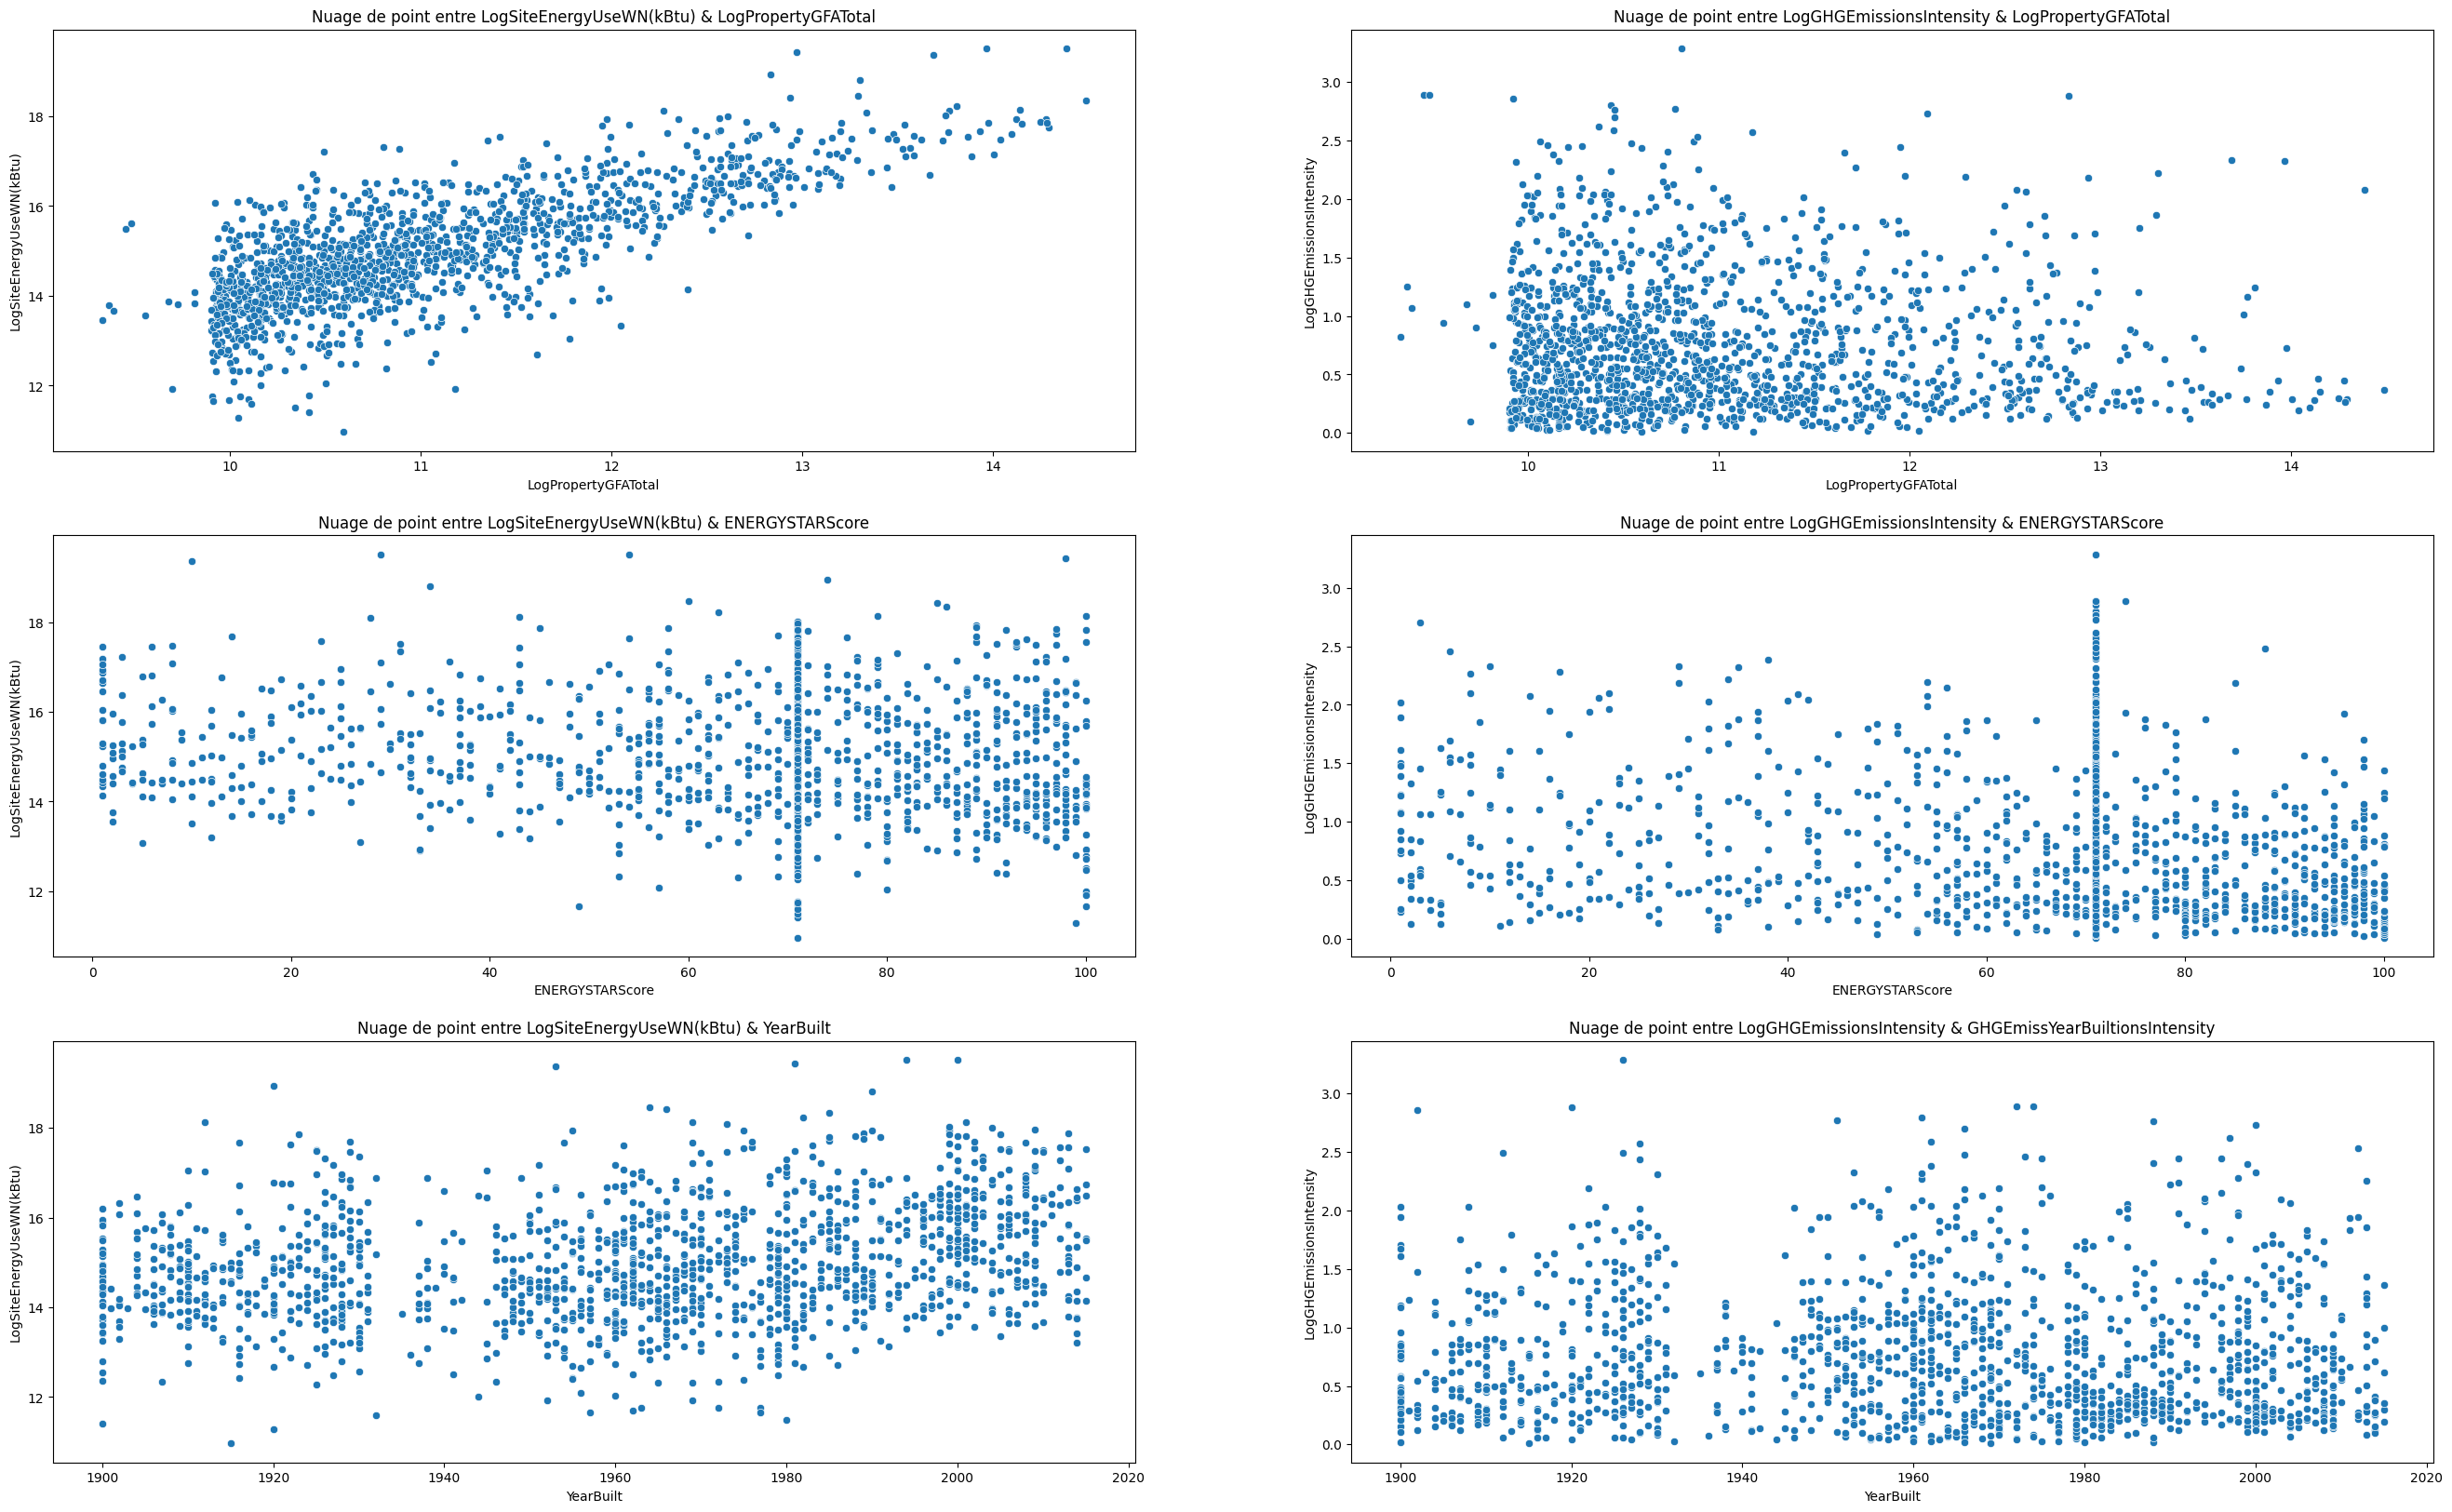

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(33,20))

# Graphe pour variable cible LogSiteEnergyUseWN(kBtu)
sns.scatterplot(data=building_consumption, y="LogSiteEnergyUseWN(kBtu)", x="LogPropertyGFATotal", 
                ax=axes[0][0]).set_title("Nuage de point entre LogSiteEnergyUseWN(kBtu) & LogPropertyGFATotal")
sns.scatterplot(data=building_consumption, y="LogSiteEnergyUseWN(kBtu)", x="ENERGYSTARScore",
                 ax=axes[1][0]).set_title("Nuage de point entre LogSiteEnergyUseWN(kBtu) & ENERGYSTARScore")
sns.scatterplot(data=building_consumption, y="LogSiteEnergyUseWN(kBtu)", x="YearBuilt",
                 ax=axes[2][0]).set_title("Nuage de point entre LogSiteEnergyUseWN(kBtu) & YearBuilt")


# Graphe pour variable cible GHGEmissionsIntensity
sns.scatterplot(data=building_consumption, y="LogGHGEmissionsIntensity", x="LogPropertyGFATotal", 
                ax=axes[0][1]).set_title("Nuage de point entre LogGHGEmissionsIntensity & LogPropertyGFATotal")
sns.scatterplot(data=building_consumption, y="LogGHGEmissionsIntensity", x="ENERGYSTARScore", 
                ax=axes[1][1]).set_title("Nuage de point entre LogGHGEmissionsIntensity & ENERGYSTARScore")
sns.scatterplot(data=building_consumption, y="LogGHGEmissionsIntensity", x="YearBuilt", 
                ax=axes[2][1]).set_title("Nuage de point entre LogGHGEmissionsIntensity & GHGEmissYearBuiltionsIntensity")


In [ ]:
# Calcul des p-value et coefficient de Pearson pour target LogSiteEnergyUseWN(kBtu)
pvalue_energy_propertygfatotal = stats.pearsonr(building_consumption["LogPropertyGFATotal"], building_consumption["LogSiteEnergyUseWN(kBtu)"])
pvalue_energy_energystarscore = stats.pearsonr(building_consumption["YearBuilt"], building_consumption["LogSiteEnergyUseWN(kBtu)"])
pvalue_energy_yearbuilt = stats.pearsonr(building_consumption["YearBuilt"], building_consumption["LogSiteEnergyUseWN(kBtu)"])

# Calcul des p-value et coefficient de Pearson pour target GHGEmissionsIntensity
pvalue_ghgemission_propertygfatotal = stats.pearsonr(building_consumption["LogPropertyGFATotal"], building_consumption["LogGHGEmissionsIntensity"])
pvalue_ghgemission_energystarscore = stats.pearsonr(building_consumption["YearBuilt"], building_consumption["LogGHGEmissionsIntensity"])
pvalue_ghgemission_yearbuilt = stats.pearsonr(building_consumption["YearBuilt"], building_consumption["LogGHGEmissionsIntensity"])


print(
    f"LogSiteEnergyUseWN(kBtu) &  LogPropertyGFATotal | pvalue :  {pvalue_energy_propertygfatotal.pvalue} Coefficient de Pearson : {pvalue_energy_propertygfatotal.statistic} \n\n"
    f"LogSiteEnergyUseWN(kBtu) & EnergyStarScore | pvalue :  {pvalue_energy_energystarscore.pvalue}  Coefficient de Pearson : {pvalue_energy_energystarscore.statistic} \n\n"
    f"LogSiteEnergyUseWN(kBtu) & YearBuilt | pvalue :  {pvalue_energy_yearbuilt.pvalue}  Coefficient de Pearson : {pvalue_energy_yearbuilt.statistic} \n\n"
)

print(
    f"LogGHGEmissionsIntensity & LogPropertyGFATotal | pvalue :  {pvalue_ghgemission_propertygfatotal.pvalue} Coefficient de Pearson : {pvalue_ghgemission_propertygfatotal.statistic}\n\n"
    f"LogGHGEmissionsIntensity & EnergyStarScore : | pvalue :  {pvalue_ghgemission_energystarscore.pvalue} Coefficient de Pearson : {pvalue_ghgemission_energystarscore.statistic}\n\n"
    f"LogGHGEmissionsIntensity & YearBuilt : | pvalue :  {pvalue_ghgemission_yearbuilt.pvalue} Coefficient de Pearson : {pvalue_ghgemission_yearbuilt.statistic}\n\n"
)

LogSiteEnergyUseWN(kBtu) &  LogPropertyGFATotal | pvalue :  2.382317134405739e-288 Coefficient de Pearson : 0.7662664641903246 

LogSiteEnergyUseWN(kBtu) & EnergyStarScore | pvalue :  1.6781365678877005e-25  Coefficient de Pearson : 0.265649343475907 

LogSiteEnergyUseWN(kBtu) & YearBuilt | pvalue :  1.6781365678877005e-25  Coefficient de Pearson : 0.265649343475907 


LogGHGEmissionsIntensity & LogPropertyGFATotal | pvalue :  0.005523777811222294 Coefficient de Pearson : -0.0718280219207807

LogGHGEmissionsIntensity & EnergyStarScore : | pvalue :  0.595758964523281 Coefficient de Pearson : -0.013749848725712034

LogGHGEmissionsIntensity & YearBuilt : | pvalue :  0.595758964523281 Coefficient de Pearson : -0.013749848725712034




Visuellement, on observe une corrélation évidente entre la taille d'un batiment avec son consommation en énergie et son emission GHGE.

Pour la corrélation entre l'année de construction et la consommation en energie, celle-ci est plus subtile par graphique mais validé par une p-value.
Par contre, cela nous annule l'hypothèse d'une explication entre la consommation totalghge et l'année de construction Pvalue > 0.05

Les boxplots réalisés dans la partie précédente mettent en evidence que certains types de batiments (ex : hopital) consomment bien plus que d'autres

## 8. Feature Engineering

Pour éviter le dataleak, on va éviter d'utiliser les données d'énergie car elles donneraient directement la réponse au modèles. Par contre, on peut les transformer en colonne donnant l'info quelles sources est utilisée.

On procède de la même manière pour créer hasParking

In [ ]:
building_consumption["HasGas"] = np.where(building_consumption["NaturalGas(kBtu)"] !=0, 1, 0)
building_consumption["HasSteam"] = np.where(building_consumption["SteamUse(kBtu)"] !=0, 1, 0)
building_consumption["HasElec"] = np.where(building_consumption["Electricity(kBtu)"] !=0, 1, 0)
building_consumption["HasParking"] = np.where(building_consumption["PropertyGFAParking"] !=0, 1, 0)
building_consumption.head()

,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,...,GHGEmissionsIntensity,LogSiteEnergyUseWN(kBtu),LogPropertyGFATotal,LogPropertyGFABuilding(s),LogLargestPropertyUseTypeGFA,LogGHGEmissionsIntensity,HasGas,HasSteam,HasElec,HasParking
0,Hotel,DOWNTOWN,1927,1.0,12,88434,0,88434,Hotel,88434.0,...,2.83,15.824652,11.390023,11.390023,11.390023,1.342865,1,1,1,0
1,Hotel,DOWNTOWN,1996,1.0,11,103566,15064,88502,Hotel,83880.0,...,2.86,15.974742,11.547974,11.390792,11.337154,1.350667,1,0,1,1
2,Hotel,DOWNTOWN,1969,1.0,41,956110,196718,759392,Hotel,756493.0,...,2.19,18.118725,13.770629,13.540275,13.536450,1.160021,1,1,1,1
3,Hotel,DOWNTOWN,1926,1.0,10,61320,0,61320,Hotel,61320.0,...,4.67,15.753792,11.023878,11.023878,11.023878,1.735189,1,1,1,0
4,Hotel,DOWNTOWN,1980,1.0,18,175580,62000,113580,Hotel,123445.0,...,2.88,16.500395,12.075856,11.640272,11.723559,1.355835,1,0,1,1


Pour exploiter les données d'années, on va les regrouper par decennies

In [ ]:

building_consumption["Decennie"] = building_consumption["YearBuilt"] - (building_consumption["YearBuilt"] % 10)
building_consumption.info()

<class 'pandas.DataFrame'>
Index: 1491 entries, 0 to 3375
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   PrimaryPropertyType              1491 non-null   str    
 1   Neighborhood                     1491 non-null   str    
 2   YearBuilt                        1491 non-null   int64  
 3   NumberofBuildings                1491 non-null   float64
 4   NumberofFloors                   1491 non-null   int64  
 5   PropertyGFATotal                 1491 non-null   int64  
 6   PropertyGFAParking               1491 non-null   int64  
 7   PropertyGFABuilding(s)           1491 non-null   int64  
 8   LargestPropertyUseType           1487 non-null   str    
 9   LargestPropertyUseTypeGFA        1487 non-null   float64
 10  SecondLargestPropertyUseType     820 non-null    str    
 11  SecondLargestPropertyUseTypeGFA  820 non-null    float64
 12  ThirdLargestPropertyUseType      337

la colonne ThirdLargestPropertyUseType etant peu rempli, on peut s'en servir plutot pour savoir si un batiment à 3 usage ou plus

In [ ]:
building_consumption["HasThreePropertyUseOrMore"] = np.where(building_consumption["ThirdLargestPropertyUseType"] !=0, 1, 0)

In [ ]:
building_consumption["PrimaryPropertyType"].value_counts().index

Index(['Small- and Mid-Sized Office', 'Other', 'Warehouse', 'Large Office',
       'Mixed Use Property', 'Retail Store', 'Hotel', 'Worship Facility',
       'Distribution Center', 'K-12 School', 'Medical Office',
       'Supermarket / Grocery Store', 'Self-Storage Facility',
       'Senior Care Community', 'University', 'Refrigerated Warehouse',
       'Hospital', 'Laboratory', 'Restaurant', 'Low-Rise Multifamily'],
      dtype='str', name='PrimaryPropertyType')


Encodage de quartier
Trop de catégories pour faire du one hot encoding donc on fait un encodage binaire

In [ ]:
encoder = preprocessing.OneHotEncoder()

# One hot Encoding de Neighborhood
label_neighborhood = encoder.fit_transform(building_consumption[["Neighborhood"]])
neighborhood_onehot = pd.DataFrame.sparse.from_spmatrix(label_neighborhood, columns=encoder.categories_[0])
building_consumption = pd.concat([building_consumption, neighborhood_onehot], axis=1)

# One hot Encoding de PrimaryPropertyType
label_primary_property = encoder.fit_transform(building_consumption[["PrimaryPropertyType"]])
primary_property_onehot = pd.DataFrame.sparse.from_spmatrix(label_primary_property, columns=encoder.categories_[0])
building_consumption = pd.concat([building_consumption, primary_property_onehot], axis=1)

# One hot Encoding de LargestPropertyUseType
label_largest_property_usetype = encoder.fit_transform(building_consumption[["LargestPropertyUseType"]])
largestPropertyUseType_onehot = pd.DataFrame.sparse.from_spmatrix(label_largest_property_usetype, columns=encoder.categories_[0])
building_consumption = pd.concat([building_consumption, largestPropertyUseType_onehot], axis=1)


In [ ]:
building_consumption = building_consumption.drop(["Neighborhood", "PrimaryPropertyType"], axis=1)
display(building_consumption)

,PrimaryPropertyType,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,...,Retail Store,Self-Storage Facility,Senior Care Community,Social/Meeting Hall,Strip Mall,Supermarket/Grocery Store,Urgent Care/Clinic/Other Outpatient,Wholesale Club/Supercenter,Worship Facility,NaN
0,Hotel,1927.0,1.0,12.0,88434.0,0.0,88434.0,Hotel,88434.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Hotel,1996.0,1.0,11.0,103566.0,15064.0,88502.0,Hotel,83880.0,Parking,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Hotel,1969.0,1.0,41.0,956110.0,196718.0,759392.0,Hotel,756493.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Hotel,1926.0,1.0,10.0,61320.0,0.0,61320.0,Hotel,61320.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Hotel,1980.0,1.0,18.0,175580.0,62000.0,113580.0,Hotel,123445.0,Parking,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2488,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [ ]:
building_consumption.to_csv("../data/processed/dataset_clean.csv")

Nettoyage final des colonnes

Qelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

# Modélisation 

### Import des modules 

In [ ]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

In [ ]:
# CODE FEATURE ENGINEERING

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn 
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

In [ ]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [ ]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE